In [1]:
pip install pandas openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

users = pd.read_excel(r"C:\Users\wmdgod\Desktop\DA_practice\游戏商分\users.xlsx")
events = pd.read_excel(r"C:\Users\wmdgod\Desktop\DA_practice\游戏商分\events.xlsx")
print(users.head())
print(users.info())

print(events.head())
print(events.info())

   user_id install_date
0        1   2024-01-07
1        2   2024-01-20
2        3   2024-01-29
3        4   2024-01-15
4        5   2024-01-11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   int64         
 1   install_date  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 78.3 KB
None
   user_id event_date     event_type
0        1 2024-01-07  session_start
1        1 2024-01-08  session_start
2        1 2024-01-09  session_start
3        1 2024-01-10  session_start
4        1 2024-01-11  session_start
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27291 entries, 0 to 27290
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     27291 non-null  int64         
 1   event_da

In [4]:
df = events.merge(users, on='user_id', how='left')
df['days_diff'] = (df['event_date'] - df['install_date']).dt.days
print(df.head())
total_users = users['user_id'].nunique()
d1_users = df[df['days_diff'] == 1]['user_id'].nunique()
d1_retention = d1_users / total_users
print("D1留存率:", d1_retention)

   user_id event_date     event_type install_date  days_diff
0        1 2024-01-07  session_start   2024-01-07          0
1        1 2024-01-08  session_start   2024-01-07          1
2        1 2024-01-09  session_start   2024-01-07          2
3        1 2024-01-10  session_start   2024-01-07          3
4        1 2024-01-11  session_start   2024-01-07          4
D1留存率: 0.8188


In [7]:
d7_users = df[df['days_diff'] == 7]['user_id'].nunique()
d7_retention = d7_users / total_users
print("D7留存率:", d7_retention)
d30_users = df[df['days_diff'] == 30]['user_id'].nunique()
d30_retention = d30_users / total_users
print("D30留存率:", d30_retention)

D7留存率: 0.2422
D30留存率: 0.0024


In [8]:
cohort = df.groupby(['install_date', 'days_diff'])['user_id'].nunique().reset_index()
cohort_pivot = cohort.pivot(index='install_date', columns='days_diff', values='user_id')
cohort_pivot = cohort_pivot.div(cohort_pivot[0], axis=0)
print(cohort_pivot.head())

days_diff      0         1         2         3         4         5         6   \
install_date                                                                    
2024-01-01    1.0  0.810651  0.644970  0.544379  0.443787  0.325444  0.278107   
2024-01-02    1.0  0.829545  0.664773  0.500000  0.414773  0.340909  0.301136   
2024-01-03    1.0  0.826087  0.657609  0.521739  0.396739  0.309783  0.250000   
2024-01-04    1.0  0.839286  0.654762  0.505952  0.392857  0.327381  0.214286   
2024-01-05    1.0  0.769663  0.657303  0.522472  0.443820  0.348315  0.297753   

days_diff           7         8         9   ...        29        30        31  \
install_date                                ...                                 
2024-01-01    0.242604  0.218935  0.177515  ...       NaN       NaN       NaN   
2024-01-02    0.238636  0.198864  0.147727  ...       NaN       NaN       NaN   
2024-01-03    0.206522  0.152174  0.108696  ...  0.005435  0.005435  0.005435   
2024-01-04    0.184524  0.1

In [9]:
user_active_days = df.groupby('user_id')['days_diff'].nunique().reset_index()
user_active_days.columns = ['user_id', 'active_days']

print(user_active_days.describe())

           user_id  active_days
count  5000.000000  5000.000000
mean   2500.500000     5.458200
std    1443.520003     4.944729
min       1.000000     1.000000
25%    1250.750000     2.000000
50%    2500.500000     4.000000
75%    3750.250000     7.000000
max    5000.000000    39.000000


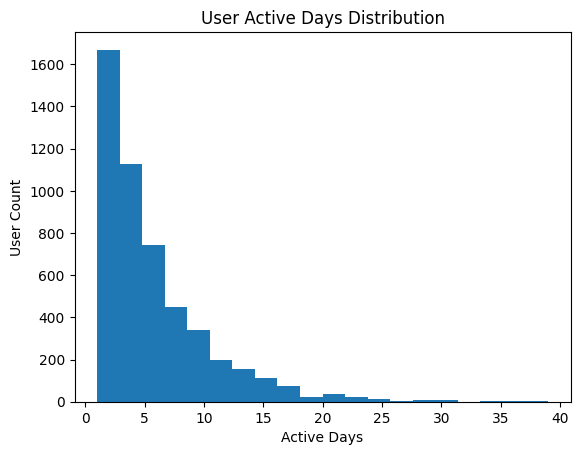

In [13]:
import matplotlib.pyplot as plt

plt.hist(user_active_days['active_days'], bins=20)
plt.title("User Active Days Distribution")
plt.xlabel("Active Days")
plt.ylabel("User Count")
plt.show()

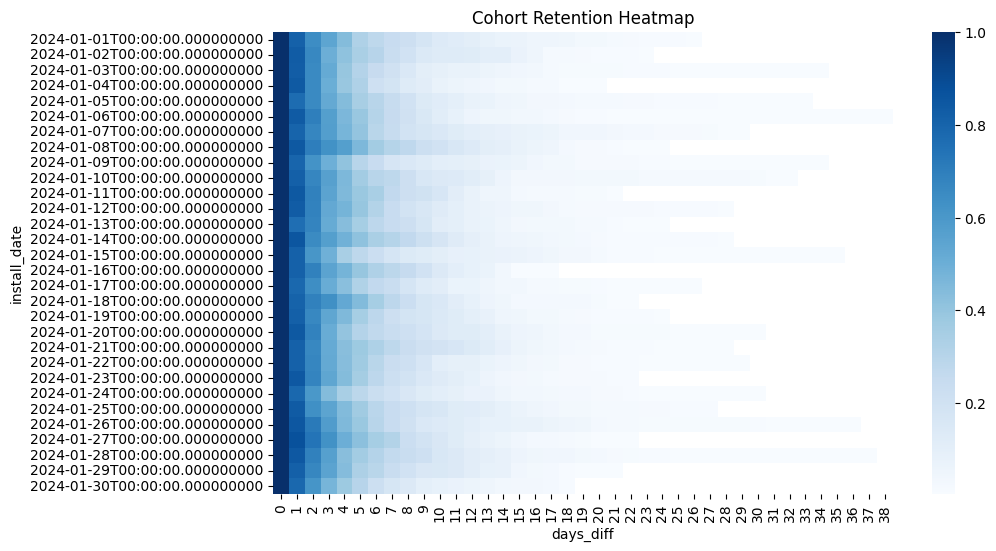

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.show()